# Chapter 1

## Aprendizado baseado em instâncias e Aprendizado baseado em modelos

### Aprendizado baseado em instâncias

Nesta abordagem, o modelo de *ML* simplesmente armazena os dados de treinamento e, quando um novo dado de entrada (uma nova instância) é apresentado, o modelo procura os dados memorizados para encontrar os mais semelhantes e faz uma previsão com base nesses dados, ou seja, o modelo precisa de uma forma metemática de medir o quão parecida uma nova instância é com as instâncias memorizadas. O conceito central é a **medida de similaridade**, pois o modelo precisa de uma métrica matemática (como a distância euclidiana) para calcular o quão "próxima" a nova instância está dos dados de treinamento armazenados. O modelo de *ML* não tenta criar uma representação geral dos dados, mas sim utiliza os dados específicos para fazer previsões. Exemplos de algoritmos de aprendizado baseado em instâncias incluem o **k-Nearest Neighbors (k-NN)** e o **Support Vector Machines (SVM)**.

### Aprendizado baseado em modelos

O aprendizado em modelos, por outro lado, não memoriza os dados de treinamento, o modelo de *ML* analisa o conjunto de dados de treinamento para detectar padrões subjacentes e constrói uma representação matemática abstrata (um modelo) desses dados. Durante a fase de treinamento, o algoritmo ajusta os parâmetros (pesos) desse modelo para que ele represente os dados da melhor forma possível. Uma vez que o modelo atinge um nível de ideal de precisão, os dados de treinamento originais tornam-se obsoletos e podem ser descartados da memória. Depois de treinado, o modelo pode fazer previsões para novos dados de entrada, mesmo que esses dados sejam diferentes dos dados de treinamento (dataset). Exemplos de algoritmos de aprendizado baseado em modelos incluem **Regressão Linear**, **Árvores de Decisão** e **Redes Neurais**.

> Ambos os paradigmas (baseado em instâncias e baseado em modelos) requerem obrigatoriamente um conjunto de dados de treinamento (dataset) para aprender, composto por um conjunto de samples (instâncias).

## Demonstração em Código: O descarte dos Dados

Vejamos um código em python. Nele, provaremos que o modelo de **Regressão Linear**, após ser treinado com um conjunto de samples (instâncias), não precisa mais delas para funcionar.

In [5]:
import numpy as np
from sklearn.linear_model import LinearRegression

# Gerando um dataset de treinamento
# Aqui teremos um conjunto de samples (instâncias)
# X_train: Anos de experiência do funcionário
# y_train: Salário em milhares de dólares
X_train = np.array([[1], [2], [3], [4], [5]])  # Características (features)
y_train = np.array([3.0, 4.5, 6.0, 7.5, 9.0])  # Alvo (target)

# Criando o modelo de Regressão Linear
model = LinearRegression()

# Fase de treinamento: O modelo aprende a partir dos dados de treinamento
# É aqui que o modelo consome as samples (instâncias) para ajustar seus parâmetros.
model.fit(X_train, y_train)

# Após o treinamento, o modelo já aprendeu a relação entre os anos de experiência e o salário.
# Agora, o modelo pode fazer previsões sem precisar dos dados de treinamento.

# Descarte dos dados de treinamento
# Vamos simular o descarte dos dados de treinamento, removendo as variáveis que contêm os dados originais.
del X_train
del y_train

# Agora, o modelo ainda pode fazer previsões mesmo sem os dados de treinamento.
# Vamos prever o salário de um funcionário com 6 anos de experiência.
X_test = np.array([[6]])  # Novo dado de entrada para previsão

# Fazendo a previsão com o modelo treinado
predicted_salary = model.predict(X_test)
print(f"Previsão do salário para um funcionário com 6 anos de experiência: {predicted_salary[0]:.2f} mil dólares")

Previsão do salário para um funcionário com 6 anos de experiência: 10.50 mil dólares


## Visão Estrutural do aprendizado baseado em modelos

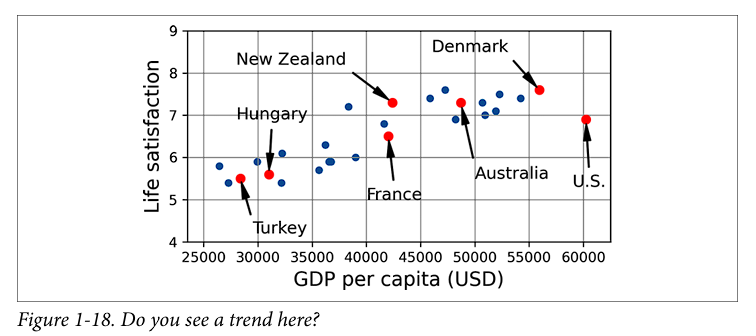

É possível observar que há uma tendência aqui! A medida que `life satisfaction` aumenta (forma linear), `GDP per capita` aumenta também. O modelo de **Regressão Linear** é capaz de capturar essa relação linear entre as duas variáveis.

A equação da linha de regressão linear é dada por:
$$y = \theta_0 + \theta_1 x$$

Onde:
- $y$ é a variável dependente (neste caso, depende de $x$ `GDP per capita`);
- $x$ é a variável independente;
- $\theta_0$ é o intercepto, também conhecido como termo constante (o valor de $y$ quando $x$ é zero);
- $\theta_1$ é o coeficiente de inclinação, também conhecido como coeficiente angular (que indica a mudança em $y$ para cada unidade de mudança em $x$).

**O atributo (feature)** usado para prever `life satisfaction` foi `GDP per capita`, e o modelo de **Regressão Linear** encontrou os melhores valores para $\theta_0$ e $\theta_1$ (parâmetros) que minimizam a diferença entre as previsões do modelo e os valores reais de `life satisfaction` nos dados de treinamento. Para saber se a reta está boa ou ruim, o algoritmo utiliza **função de custo** (*cost function*), que mede a distância média entre a reta do modelo e os pontos de dados reais. O objetivo do treinamento é minimizar esse custo, ou seja, tornar as distâncias entre a reta e os pontos as menores possíveis.

No exemplo anterior, o modelo de **Regressão Linear** encontrou os melhores valores para $\theta_0$ e $\theta_1$ (parâmetros da reta) que minimizam a função de custo, mas não olhamos "dentro" do modelo para ver quais são esses valores. Quando treinamos um **modelo linear**, o `Scikit-Learn` calcula exatamente esses parâmetros da reta ($\theta_0$ e $\theta_1$) e os armazena como atributos do modelo. Podemos acessar esses parâmetros usando os atributos `intercept_` e `coef_` do modelo treinado.

In [29]:
# Dados de treinamento
X_treino = np.array(
    [
        [20000],
        [30000],
        [40000],
        [50000],
        [60000]
    ]
)

y_treino = np.array([5.5, 6.0, 6.5, 7.0, 7.5])

# Criando uma instância do modelo de Regressão Linear
modelo = LinearRegression()

# Treinando o modelo com os dados de treinamento
modelo.fit(X_treino, y_treino)

# Agora, vamos extrair os parâmetros do modelo treinado
theta_0 = format(modelo.intercept_, ".4f").replace(".", ",")  # Intercepto (termo independente)
theta_1 = format(modelo.coef_[0], ".4f").replace(".", ",")    # Coeficiente (coeficiente angular)

print("-" * 60)
print("Paramêtros Encontrados pelo Modelo de Regressão Linear")
print("-" * 60)

print(f"Intercepto (theta_0): {theta_0}")
print(f"Coeficiente (theta_1): {theta_1}")
print(f"A equação da reta é: y = {theta_0} + {theta_1} * x")

------------------------------------------------------------
Paramêtros Encontrados pelo Modelo de Regressão Linear
------------------------------------------------------------
Intercepto (theta_0): 4,5000
Coeficiente (theta_1): 0,0001
A equação da reta é: y = 4,5000 + 0,0001 * x
